In [332]:
import pandas as pd

df = pd.read_csv("Google_Stock_Price_Train.csv")


In [333]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [334]:
df.shape

(1258, 6)

In [335]:
training_set = df.iloc[:, 1:2].values

In [336]:
training_set[:5]

array([[325.25],
       [331.27],
       [329.83],
       [328.34],
       [322.04]])

***Next, we have to perform normalization of data using scaling. Our data will be scaled into a specific format. So we need the MinMaxScaler library as well***

In [337]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = sc.fit_transform(training_set)
training_set_scaled

array([[0.08581368],
       [0.09701243],
       [0.09433366],
       ...,
       [0.95725128],
       [0.93796041],
       [0.93688146]], shape=(1258, 1))



***Now, we will create a data structure with 60 timesteps and one output as an Array of x_train and y_train***

In [338]:
import numpy as np

X_train = []
y_train = []
for i in range(60, 1258):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [339]:
X_train.shape

(1198, 60)

***Here we have done reshaping of x_train data***

In [340]:
X_train = X_train.reshape(1198, 60, 1)
X_train.shape

(1198, 60, 1)

In [341]:
##X_train = X_train.reshape(1198, 60, 1)

***We need to reshape it because 
samples = 1198 ✔
timesteps = 60 ✔
features = ❌ missing***

In [342]:
X_train.shape

(1198, 60, 1)

***Sample = 1198 ✔
timesteps()  = 60 ✔
features = 1 ✔***

***If we have data Day***

1: 100  
Day 2: 102  
Day 3: 101  
Day 4: 105  
Day 5: 110

***If timesteps = 3***
#### Sample 1
Input  → [100, 102, 101]
Target → 105

#### Sample 2
Input  → [102, 101, 105]
Target → 110
#### timesteps = how many previous days you look at 


In [343]:
X_train[:3]

array([[[0.08581368],
        [0.09701243],
        [0.09433366],
        [0.09156187],
        [0.07984225],
        [0.0643277 ],
        [0.0585423 ],
        [0.06568569],
        [0.06109085],
        [0.06639259],
        [0.0614257 ],
        [0.07474514],
        [0.02797827],
        [0.02379269],
        [0.02409033],
        [0.0159238 ],
        [0.01078949],
        [0.00967334],
        [0.01642607],
        [0.02100231],
        [0.02280676],
        [0.02273235],
        [0.02810849],
        [0.03212665],
        [0.0433812 ],
        [0.04475779],
        [0.04790163],
        [0.0440695 ],
        [0.04648783],
        [0.04745517],
        [0.04873875],
        [0.03936305],
        [0.04137213],
        [0.04034898],
        [0.04784582],
        [0.04325099],
        [0.04356723],
        [0.04286033],
        [0.04602277],
        [0.05398467],
        [0.05738894],
        [0.05714711],
        [0.05569611],
        [0.04421832],
        [0.04514845],
        [0

In [344]:
y_train.shape

(1198,)

In [345]:
y_train[:5]

array([0.08627874, 0.08471612, 0.07454052, 0.07883771, 0.07238262])

***Now, the following libraries are required for building the RNN model and perform its operations. We have imported the Keras library and its packages.***

In [346]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

***Build the Model***

In [347]:
model = Sequential()

model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

model.add(SimpleRNN(units=50))
model.add(Dropout(0.2))

model.add(Dense(units=1))

C:\Users\muhammad.fayaz\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


***Compile the Model***

In [348]:
model.compile(optimizer='adam', loss='mean_squared_error')

***Train the Model***

In [349]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 0.0984
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0273 
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0188 
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0136 
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0106 
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0095 
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0078 
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0076 
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0065 
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0057 
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0058 
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0058 
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0055 
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0048 
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss

***Prediction on training data***

In [350]:
predicted_train = model.predict(X_train)

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step


***Transform to Actual***

In [351]:
# Inverse transform
predicted_train = sc.inverse_transform(predicted_train.reshape(-1, 1))
real_train = sc.inverse_transform(y_train.reshape(-1, 1))

***Visualization***

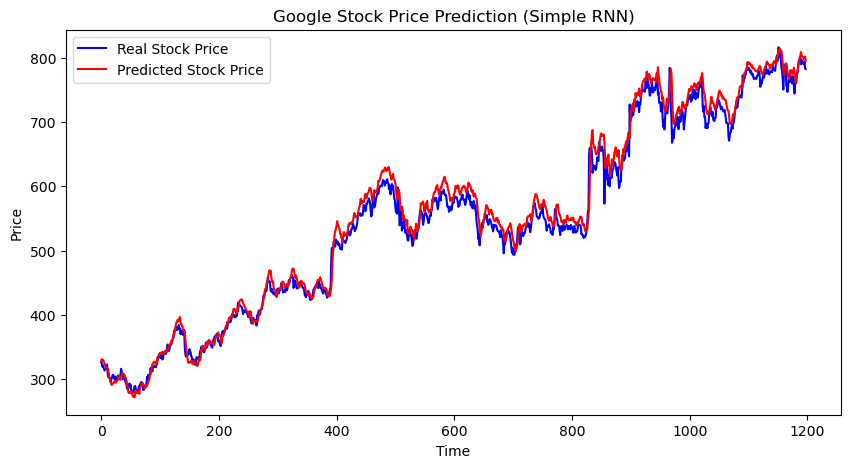

In [352]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(real_train, color='blue', label='Real Stock Price')
plt.plot(predicted_train, color='red', label='Predicted Stock Price')
plt.title('Google Stock Price Prediction (Simple RNN)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [355]:
rnn_layer = model.layers[0]   # first RNN layer
weights = rnn_layer.get_weights()

Wx = weights[0]   # input → hidden
Wh = weights[1]   # hidden → hidden
hO = weights[2]  # hidden → output
b  = weights[2]   # bias

print("Wx shape:", Wx.shape)
print("Wh shape:", Wh.shape)
print("hO shape:", hO.shape)

Wx shape: (1, 50)
Wh shape: (50, 50)
hO shape: (50,)
